# Valor del Dinero en el Tiempo: Fórmulas Cuantitativas Esenciales
## Carrusel A — Serie Quant · WP Wellness Academy

## Recursos del Autor

| Recurso | Descripción | Enlace |
|---------|-------------|--------|
| **eBook: Finanzas 5.0** | Enfoque moderno basado en datos y Python | [wpwellnessacademy.com](https://www.wpwellnessacademy.com/finanzas-50-un-enfoque-moderno-basado-en-datos-y-python-ebook-digital) |
| **Curso Profesional Python para Finanzas 5.0** | Formación completa de economista cuantitativo | [wpwellnessacademy.com](https://www.wpwellnessacademy.com/curso-profesional-python-para-finanzas-50) |

---

## Tabla de Contenidos

1. [Valor Futuro (FV)](#fv) — Ross, Westerfield & Jordan (2019)
2. [Valor Presente (PV)](#pv) — Brealey, Myers & Allen (2020)
3. [Capitalización Continua](#continua) — Hull (2018)
4. [Valor Presente Neto (VPN/NPV)](#npv) — Damodaran (2012)
5. [CAGR — Tasa de Crecimiento Compuesto Anual](#cagr) — Damodaran (2012)
6. [TIR — Tasa Interna de Retorno](#irr) — Brealey, Myers & Allen (2020)
7. [WACC — Costo Promedio Ponderado del Capital](#wacc) — Koller, Goedhart & Wessels (2020)

---

### Referencias Académicas
- Ross, S., Westerfield, R., & Jordan, B. (2019). *Corporate Finance* (12th ed.). McGraw-Hill.
- Brealey, R., Myers, S., & Allen, F. (2020). *Principles of Corporate Finance* (13th ed.). McGraw-Hill.
- Hull, J. C. (2018). *Options, Futures, and Other Derivatives* (10th ed.). Pearson.
- Damodaran, A. (2012). *Investment Valuation* (3rd ed.). Wiley.
- Koller, T., Goedhart, M., & Wessels, D. (2020). *Valuation* (7th ed.). Wiley.


In [1]:
# === CONFIGURACIÓN GLOBAL ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yfinance as yf
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

# Paleta de colores institucional
BG     = '#0A0E1A'
BG2    = '#0D1226'
CYAN   = '#00D4FF'
GOLD   = '#FFD700'
RED    = '#FF4444'
GREEN  = '#00FF88'
WHITE  = '#FFFFFF'
GRAY   = '#8892A4'

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG2,
    'axes.edgecolor':   GRAY,
    'axes.labelcolor':  WHITE,
    'xtick.color':      GRAY,
    'ytick.color':      GRAY,
    'text.color':       WHITE,
    'grid.color':       '#1E2A3A',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'figure.dpi':       120,
})

print('✅ Configuración cargada — WP Wellness Academy · Curso Python para Finanzas 5.0')


✅ Configuración cargada — WP Wellness Academy · Curso Python para Finanzas 5.0


---
## 1. Valor Futuro (FV) <a id='fv'></a>

> *"El dinero tiene un valor diferente en el tiempo debido al potencial de crecimiento."*
> — Ross, Westerfield & Jordan, *Corporate Finance* (2019)

### Fórmula

$$FV = PV \times (1 + r)^n$$

| Parámetro | Definición |
|---|---|
| $FV$ | Valor Futuro |
| $PV$ | Valor Presente (capital inicial) |
| $r$ | Tasa de interés anual |
| $n$ | Número de períodos (años) |

**Interpretación:** Un capital de \$10,000 invertido al 8% anual durante 10 años crece a \$21,589.


[*********************100%***********************]  3 of 3 completed



📊 Valor Futuro Real (2014 → 2024):
          PV      FV  CAGR
AAPL   17.12  190.38  0.27
MSFT   30.69  368.87  0.28
SPY   148.58  462.58  0.12


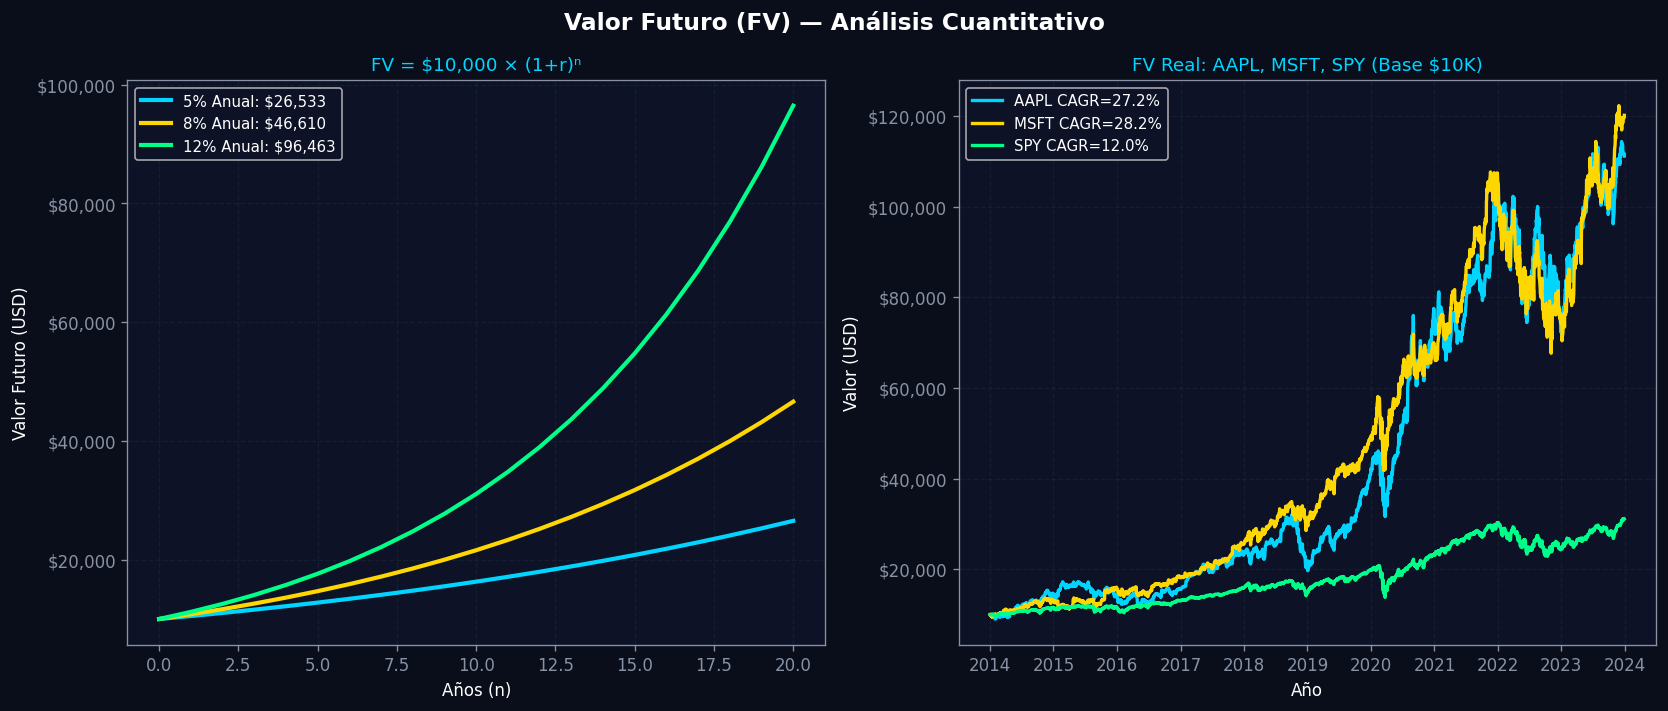

In [2]:
# === VALOR FUTURO (FV) ===
# Aplicado a datos reales: AAPL, MSFT, SPY

tickers = ['AAPL', 'MSFT', 'SPY']
data = yf.download(tickers, start='2014-01-01', end='2024-01-01', auto_adjust=True)['Close']

# Calcular CAGR implícito (FV/PV)^(1/n) - 1
n_years = 10
results = {}
for t in tickers:
    pv = data[t].dropna().iloc[0]
    fv = data[t].dropna().iloc[-1]
    cagr = (fv / pv) ** (1 / n_years) - 1
    results[t] = {'PV': pv, 'FV': fv, 'CAGR': cagr}

df_results = pd.DataFrame(results).T
print("\n📊 Valor Futuro Real (2014 → 2024):")
print(df_results.round(2).to_string())

# Visualización: FV teórico vs tasas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Valor Futuro (FV) — Análisis Cuantitativo', color=WHITE, fontsize=14, fontweight='bold')

# Panel 1: FV a distintas tasas
pv0 = 10_000
rates = [0.05, 0.08, 0.12]
colors_r = [CYAN, GOLD, GREEN]
labels_r = ['5% Anual', '8% Anual', '12% Anual']
years = np.arange(0, 21)
ax1 = axes[0]
for r, c, lbl in zip(rates, colors_r, labels_r):
    fv_series = pv0 * (1 + r) ** years
    ax1.plot(years, fv_series, color=c, linewidth=2.5, label=f'{lbl}: ${fv_series[-1]:,.0f}')
ax1.set_title('FV = $10,000 × (1+r)ⁿ', color=CYAN, fontsize=11)
ax1.set_xlabel('Años (n)')
ax1.set_ylabel('Valor Futuro (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=9)
ax1.grid(True)

# Panel 2: Precios reales AAPL, MSFT, SPY normalizados a $10,000
ax2 = axes[1]
for t, c in zip(tickers, [CYAN, GOLD, GREEN]):
    series = data[t].dropna()
    normalized = series / series.iloc[0] * 10_000
    cagr_val = results[t]['CAGR'] * 100
    ax2.plot(series.index, normalized, color=c, linewidth=2, label=f'{t} CAGR={cagr_val:.1f}%')
ax2.set_title('FV Real: AAPL, MSFT, SPY (Base $10K)', color=CYAN, fontsize=11)
ax2.set_xlabel('Año')
ax2.set_ylabel('Valor (USD)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.legend(fontsize=9)
ax2.grid(True)

plt.tight_layout()
plt.show()


---
## 2. Valor Presente (PV) <a id='pv'></a>

> *"Un peso hoy vale más que un peso mañana."*
> — Brealey, Myers & Allen, *Principles of Corporate Finance* (2020)

### Fórmula

$$PV = \frac{FV}{(1 + r)^n}$$

| Parámetro | Definición |
|---|---|
| $PV$ | Valor Presente |
| $FV$ | Flujo futuro esperado |
| $r$ | Tasa de descuento (WACC) |
| $n$ | Número de períodos |

**Aplicación:** El descuento de flujos de caja es la base del modelo DCF (Discounted Cash Flow).


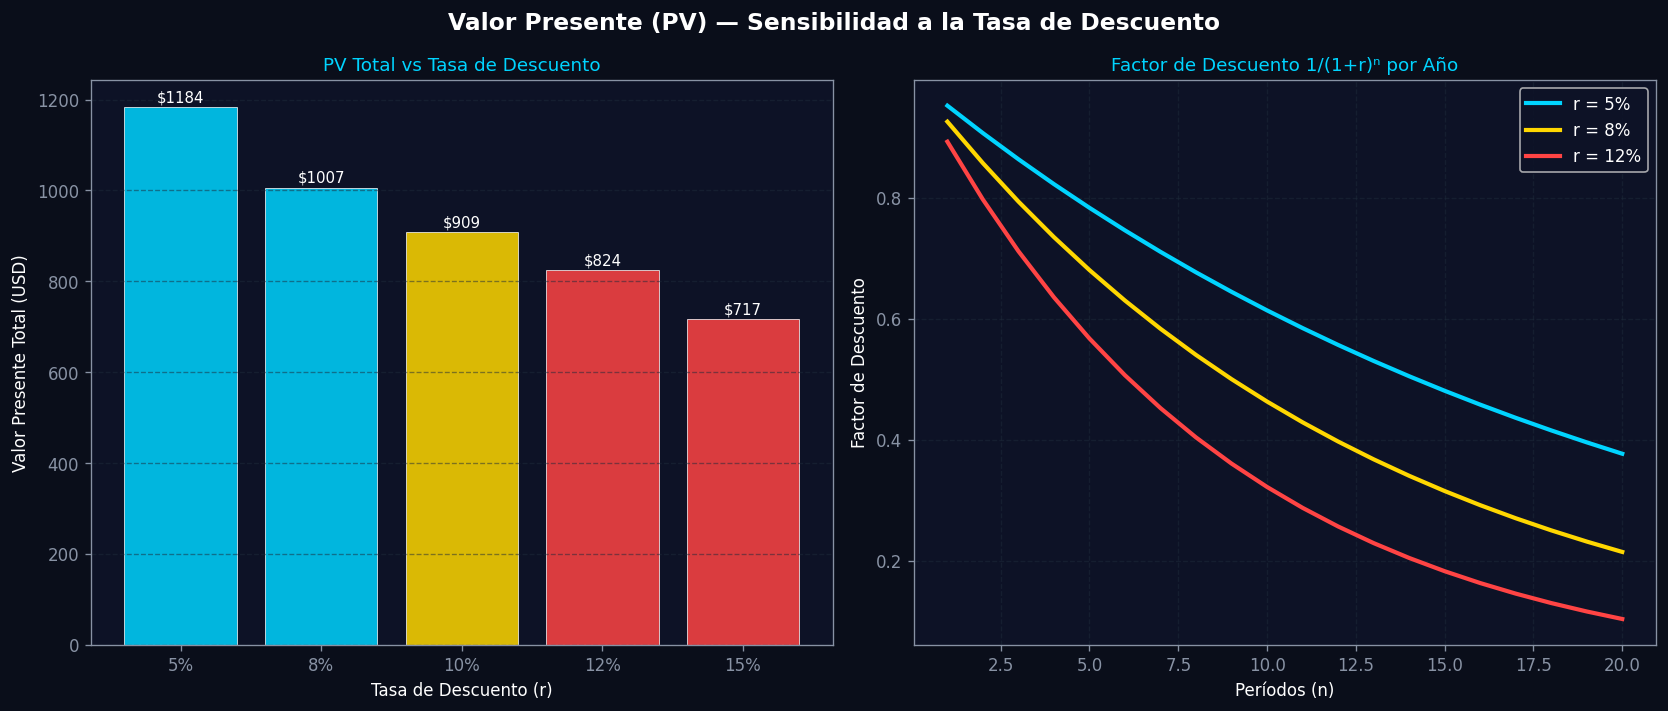


💡 A mayor tasa de descuento, menor es el valor presente de los flujos futuros.


In [3]:
# === VALOR PRESENTE (PV) — Descuento de Flujos ===
# Aplicado a dividendos reales de KO (Coca-Cola)

# Descuento de flujos futuros hipotéticos con tasas reales
discount_rates = [0.05, 0.08, 0.10, 0.12, 0.15]
cash_flows = [100, 110, 121, 133, 146, 161, 177, 195, 214, 236]  # CF creciendo 10% anual
n_periods = len(cash_flows)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Valor Presente (PV) — Sensibilidad a la Tasa de Descuento', color=WHITE, fontsize=14, fontweight='bold')

# Panel 1: PV total vs tasa de descuento
pvs = []
for r in discount_rates:
    pv_total = sum(cf / (1 + r)**t for t, cf in enumerate(cash_flows, 1))
    pvs.append(pv_total)

ax1 = axes[0]
bars = ax1.bar([f'{r*100:.0f}%' for r in discount_rates], pvs,
               color=[CYAN, CYAN, GOLD, RED, RED], alpha=0.85, edgecolor=WHITE, linewidth=0.5)
for bar, pv in zip(bars, pvs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'${pv:.0f}', ha='center', va='bottom', color=WHITE, fontsize=9)
ax1.set_title('PV Total vs Tasa de Descuento', color=CYAN, fontsize=11)
ax1.set_xlabel('Tasa de Descuento (r)')
ax1.set_ylabel('Valor Presente Total (USD)')
ax1.grid(True, axis='y')

# Panel 2: Perfil temporal de descuento
ax2 = axes[1]
t_range = np.arange(1, 21)
for r, c in zip([0.05, 0.08, 0.12], [CYAN, GOLD, RED]):
    pv_factor = 1 / (1 + r) ** t_range
    ax2.plot(t_range, pv_factor, color=c, linewidth=2.5, label=f'r = {r*100:.0f}%')
ax2.set_title('Factor de Descuento 1/(1+r)ⁿ por Año', color=CYAN, fontsize=11)
ax2.set_xlabel('Períodos (n)')
ax2.set_ylabel('Factor de Descuento')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\n💡 A mayor tasa de descuento, menor es el valor presente de los flujos futuros.")


---
## 3. Capitalización Continua <a id='continua'></a>

> *"La capitalización continua es el límite matemático de la capitalización discreta cuando el número de períodos tiende a infinito."*
> — Hull, *Options, Futures, and Other Derivatives* (2018)

### Fórmula

$$A = P \cdot e^{rt}$$

| Parámetro | Definición |
|---|---|
| $A$ | Monto final |
| $P$ | Capital inicial |
| $r$ | Tasa de interés continua |
| $t$ | Tiempo en años |
| $e$ | Número de Euler ≈ 2.71828 |

**Aplicación en derivados:** La capitalización continua es estándar en la fórmula de Black-Scholes y en la valoración de bonos.


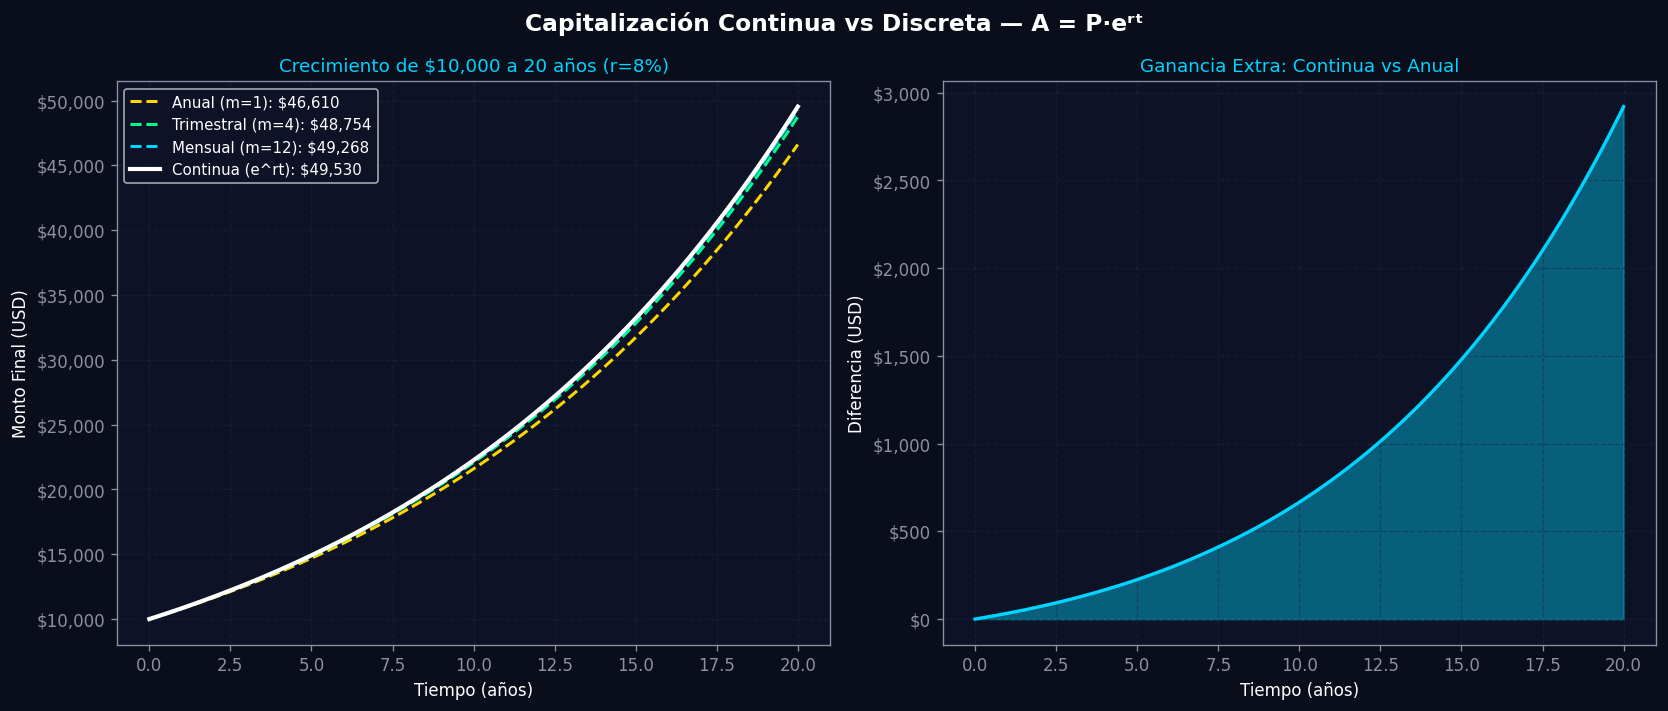


📊 Comparación a t=10 años (P=$10,000, r=8%):
  Anual (m=1)           : $ 21,672.91
  Trimestral (m=4)      : $ 22,168.46
  Mensual (m=12)        : $ 22,285.52
  Continua (e^rt)       : $ 22,345.06


In [4]:
# === CAPITALIZACIÓN CONTINUA ===
import numpy as np

P = 10_000  # Capital inicial
r = 0.08    # Tasa anual
t = np.linspace(0, 20, 200)

# Comparación: anual, trimestral, mensual, continua
compounding = {
    'Anual (m=1)':       P * (1 + r/1)   ** (1*t),
    'Trimestral (m=4)':  P * (1 + r/4)   ** (4*t),
    'Mensual (m=12)':    P * (1 + r/12)  ** (12*t),
    'Continua (e^rt)':   P * np.exp(r*t),
}
colors_c = [GOLD, GREEN, CYAN, WHITE]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Capitalización Continua vs Discreta — A = P·eʳᵗ', color=WHITE, fontsize=14, fontweight='bold')

ax1 = axes[0]
for (label, values), c in zip(compounding.items(), colors_c):
    ax1.plot(t, values, color=c, linewidth=2.5 if 'Continua' in label else 1.8,
             linestyle='-' if 'Continua' in label else '--', label=f'{label}: ${values[-1]:,.0f}')
ax1.set_title('Crecimiento de $10,000 a 20 años (r=8%)', color=CYAN, fontsize=11)
ax1.set_xlabel('Tiempo (años)')
ax1.set_ylabel('Monto Final (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=9)
ax1.grid(True)

# Panel 2: Diferencia entre continua y anual
diff = compounding['Continua (e^rt)'] - compounding['Anual (m=1)']
ax2 = axes[1]
ax2.fill_between(t, diff, alpha=0.4, color=CYAN)
ax2.plot(t, diff, color=CYAN, linewidth=2)
ax2.set_title('Ganancia Extra: Continua vs Anual', color=CYAN, fontsize=11)
ax2.set_xlabel('Tiempo (años)')
ax2.set_ylabel('Diferencia (USD)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(True)

plt.tight_layout()
plt.show()

# Tabla comparativa a t=10
print("\n📊 Comparación a t=10 años (P=$10,000, r=8%):")
for label, values in compounding.items():
    idx = np.searchsorted(t, 10)
    print(f"  {label:<22}: ${values[idx]:>10,.2f}")


---
## 4. Valor Presente Neto (VPN / NPV) <a id='npv'></a>

> *"Un proyecto crea valor si su VPN es positivo; destruye valor si es negativo."*
> — Damodaran, *Investment Valuation* (2012)

### Fórmula

$$VPN = \sum_{t=1}^{n} \frac{CF_t}{(1+r)^t} - I_0$$

| Parámetro | Definición |
|---|---|
| $CF_t$ | Flujo de caja en el período $t$ |
| $r$ | Tasa de descuento (WACC) |
| $I_0$ | Inversión inicial |
| $n$ | Horizonte del proyecto |

**Regla de decisión:** Invertir si VPN > 0; rechazar si VPN < 0.


📊 Análisis VPN (WACC = 10%)
  Proyecto A: VPN = $29,078.68  ✅ ACEPTAR
  Proyecto B: VPN = $19,118.48  ✅ ACEPTAR


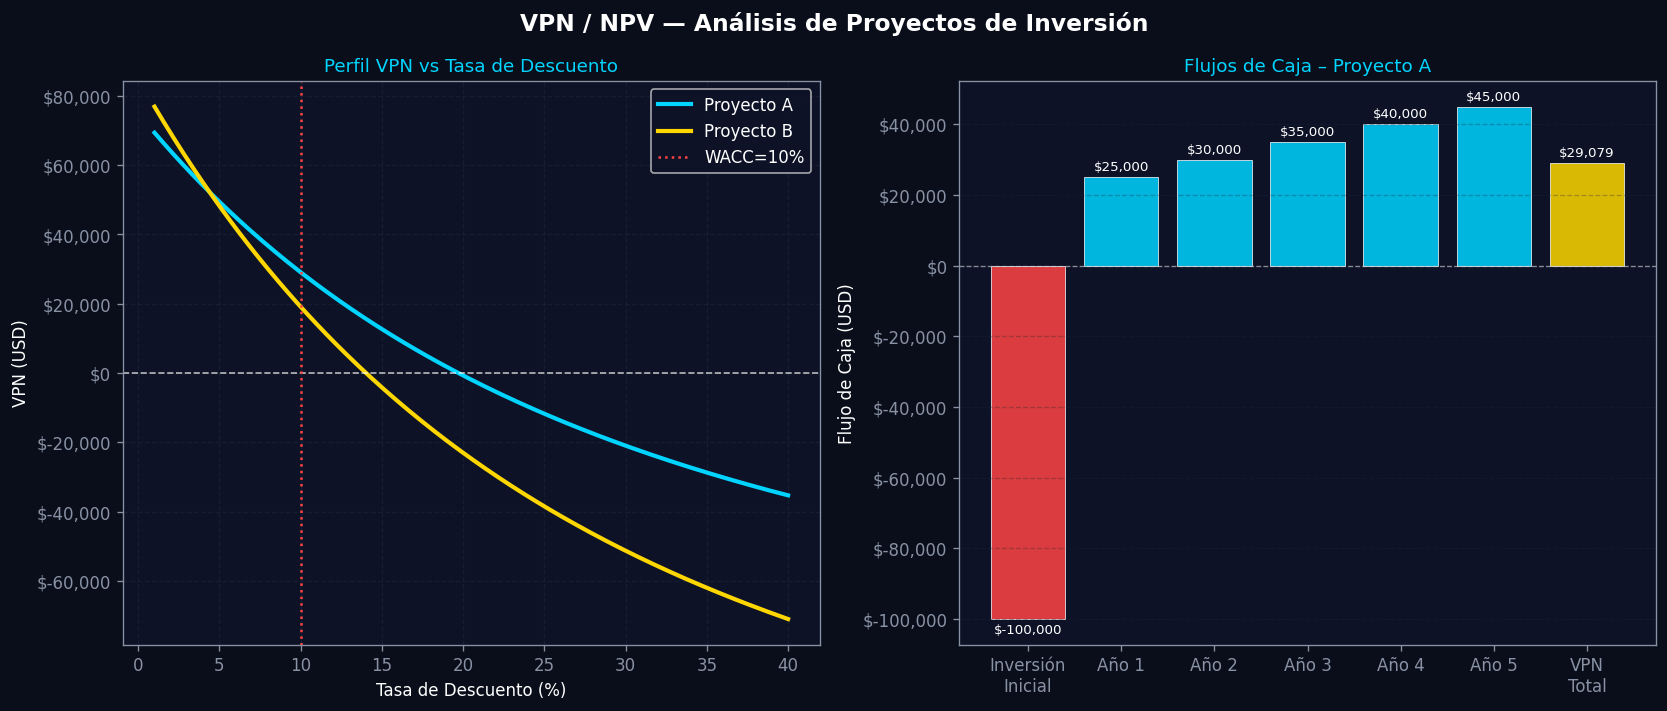

In [6]:
# === VPN / NPV — Análisis de Proyectos de Inversión ===

def npv(rate, cash_flows):
    """Calcula el VPN dados una tasa y flujos de caja."""
    return sum(cf / (1 + rate)**t for t, cf in enumerate(cash_flows))

# Proyecto A: Inversión en tecnología
cf_proyecto_a = [-100_000, 25_000, 30_000, 35_000, 40_000, 45_000]
# Proyecto B: Expansión de capacidad
cf_proyecto_b = [-150_000, 20_000, 35_000, 50_000, 60_000, 70_000]

wacc = 0.10  # 10% WACC

npv_a = npv(wacc, cf_proyecto_a)
npv_b = npv(wacc, cf_proyecto_b)

print(f"📊 Análisis VPN (WACC = {wacc*100:.0f}%)")
print(f"  Proyecto A: VPN = ${npv_a:,.2f}  {'✅ ACEPTAR' if npv_a > 0 else '❌ RECHAZAR'}")
print(f"  Proyecto B: VPN = ${npv_b:,.2f}  {'✅ ACEPTAR' if npv_b > 0 else '❌ RECHAZAR'}")

# Perfil de VPN vs tasa de descuento
rates_range = np.linspace(0.01, 0.40, 200)
npv_a_profile = [npv(r, cf_proyecto_a) for r in rates_range]
npv_b_profile = [npv(r, cf_proyecto_b) for r in rates_range]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('VPN / NPV — Análisis de Proyectos de Inversión', color=WHITE, fontsize=14, fontweight='bold')

ax1 = axes[0]
ax1.plot(rates_range * 100, npv_a_profile, color=CYAN, linewidth=2.5, label='Proyecto A')
ax1.plot(rates_range * 100, npv_b_profile, color=GOLD, linewidth=2.5, label='Proyecto B')
ax1.axhline(0, color=WHITE, linestyle='--', linewidth=1, alpha=0.7)
ax1.axvline(wacc * 100, color=RED, linestyle=':', linewidth=1.5, label=f'WACC={wacc*100:.0f}%')
ax1.set_title('Perfil VPN vs Tasa de Descuento', color=CYAN, fontsize=11)
ax1.set_xlabel('Tasa de Descuento (%)')
ax1.set_ylabel('VPN (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend()
ax1.grid(True)

# Waterfall chart del Proyecto A
# Waterfall Chart del Proyecto A
ax2 = axes[1]

labels_wf = [
    'Inversión\nInicial',
    'Año 1',
    'Año 2',
    'Año 3',
    'Año 4',
    'Año 5',
    'VPN\nTotal'
]

values_wf = cf_proyecto_a + [npv_a]

colors_wf = [RED] + [CYAN] * 5 + [GOLD]

bars2 = ax2.bar(
    labels_wf,
    values_wf,
    color=colors_wf,
    alpha=0.85,
    edgecolor=WHITE,
    linewidth=0.5
)

for bar, val in zip(bars2, values_wf):
    y_pos = bar.get_height() + 1000 if val >= 0 else bar.get_height() - 5000

    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        y_pos,
        f'${val:,.0f}',
        ha='center',
        va='bottom',
        color=WHITE,
        fontsize=8
    )

ax2.axhline(
    0,
    color=WHITE,
    linestyle='--',
    linewidth=0.8,
    alpha=0.5
)

ax2.set_title(
    'Flujos de Caja – Proyecto A',
    color=CYAN,
    fontsize=11
)

ax2.set_ylabel(
    'Flujo de Caja (USD)',
    color=WHITE
)

ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. CAGR — Tasa de Crecimiento Compuesto Anual <a id='cagr'></a>

> *"El CAGR es la tasa de retorno que se necesitaría para que una inversión crezca de su saldo inicial a su saldo final, asumiendo que las ganancias se reinvierten cada año."*
> — Damodaran, *Investment Valuation* (2012)

### Fórmula

$$CAGR = \left(\frac{VF}{VI}\right)^{\frac{1}{n}} - 1$$

| Parámetro | Definición |
|---|---|
| $VF$ | Valor Final |
| $VI$ | Valor Inicial |
| $n$ | Número de años |

**Ventaja:** El CAGR elimina la volatilidad interanual y muestra el crecimiento "suavizado".


[*********************100%***********************]  5 of 5 completed


📊 CAGR Real (2014 → 2024, 10 años):
  MSFT  : 28.23%
  AAPL  : 27.23%
  GOOGL : 17.50%
  JPM   : 14.40%
  SPY   : 12.03%


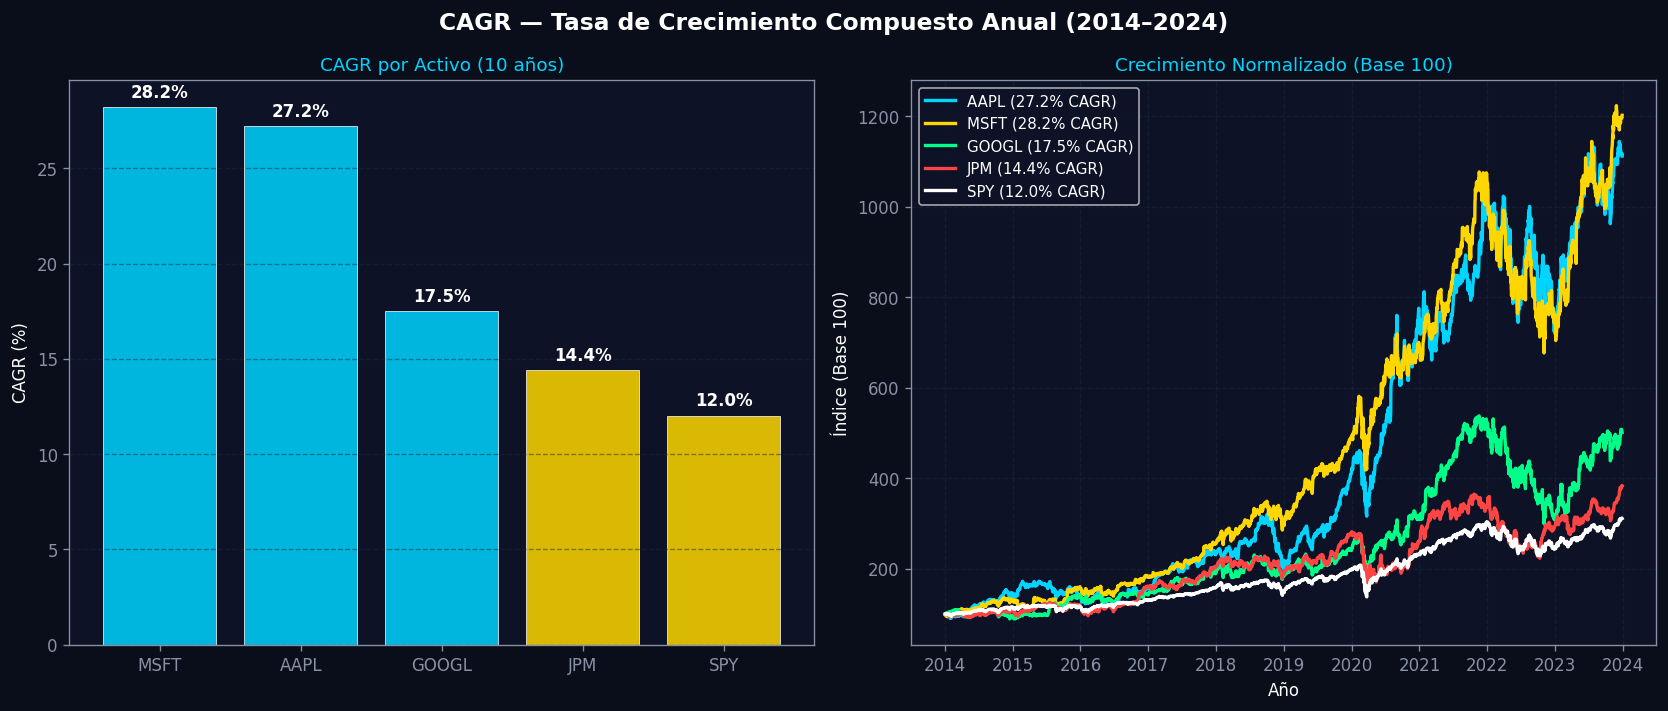

In [7]:
# === CAGR — Aplicado a Activos Reales ===

tickers_cagr = ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'SPY']
data_cagr = yf.download(tickers_cagr, start='2014-01-01', end='2024-01-01', auto_adjust=True)['Close']

def calc_cagr(series, years):
    vi = series.dropna().iloc[0]
    vf = series.dropna().iloc[-1]
    return (vf / vi) ** (1 / years) - 1

n = 10
cagr_results = {t: calc_cagr(data_cagr[t], n) for t in tickers_cagr}

print("📊 CAGR Real (2014 → 2024, 10 años):")
for t, c in sorted(cagr_results.items(), key=lambda x: -x[1]):
    print(f"  {t:<6}: {c*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('CAGR — Tasa de Crecimiento Compuesto Anual (2014–2024)', color=WHITE, fontsize=14, fontweight='bold')

# Panel 1: Barras CAGR
ax1 = axes[0]
sorted_items = sorted(cagr_results.items(), key=lambda x: -x[1])
tks = [x[0] for x in sorted_items]
cagrs = [x[1] * 100 for x in sorted_items]
bar_colors = [CYAN if c > 15 else GOLD if c > 10 else GREEN for c in cagrs]
bars = ax1.bar(tks, cagrs, color=bar_colors, alpha=0.85, edgecolor=WHITE, linewidth=0.5)
for bar, val in zip(bars, cagrs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', color=WHITE, fontsize=10, fontweight='bold')
ax1.set_title('CAGR por Activo (10 años)', color=CYAN, fontsize=11)
ax1.set_ylabel('CAGR (%)')
ax1.grid(True, axis='y')

# Panel 2: Crecimiento normalizado
ax2 = axes[1]
for t, c in zip(tickers_cagr, [CYAN, GOLD, GREEN, RED, WHITE]):
    series = data_cagr[t].dropna()
    normalized = series / series.iloc[0] * 100
    cagr_val = cagr_results[t] * 100
    ax2.plot(series.index, normalized, color=c, linewidth=2, label=f'{t} ({cagr_val:.1f}% CAGR)')
ax2.set_title('Crecimiento Normalizado (Base 100)', color=CYAN, fontsize=11)
ax2.set_xlabel('Año')
ax2.set_ylabel('Índice (Base 100)')
ax2.legend(fontsize=9)
ax2.grid(True)

plt.tight_layout()
plt.show()


---
## 6. TIR — Tasa Interna de Retorno (IRR) <a id='irr'></a>

> *"La TIR es la tasa de descuento que hace que el VPN de todos los flujos de caja sea igual a cero."*
> — Brealey, Myers & Allen, *Principles of Corporate Finance* (2020)

### Fórmula

$$0 = \sum_{t=0}^{n} \frac{CF_t}{(1+TIR)^t}$$

| Parámetro | Definición |
|---|---|
| $TIR$ | Tasa Interna de Retorno |
| $CF_t$ | Flujo de caja en el período $t$ |
| $n$ | Horizonte del proyecto |

**Regla de decisión:** Invertir si TIR > WACC; rechazar si TIR < WACC.


📊 Análisis TIR vs WACC (10%):
  Proyecto A (Tecnología)            : TIR = 19.71%  ✅ ACEPTAR
  Proyecto B (Expansión)             : TIR = 14.02%  ✅ ACEPTAR
  Proyecto C (Conservador)           : TIR = 14.61%  ✅ ACEPTAR


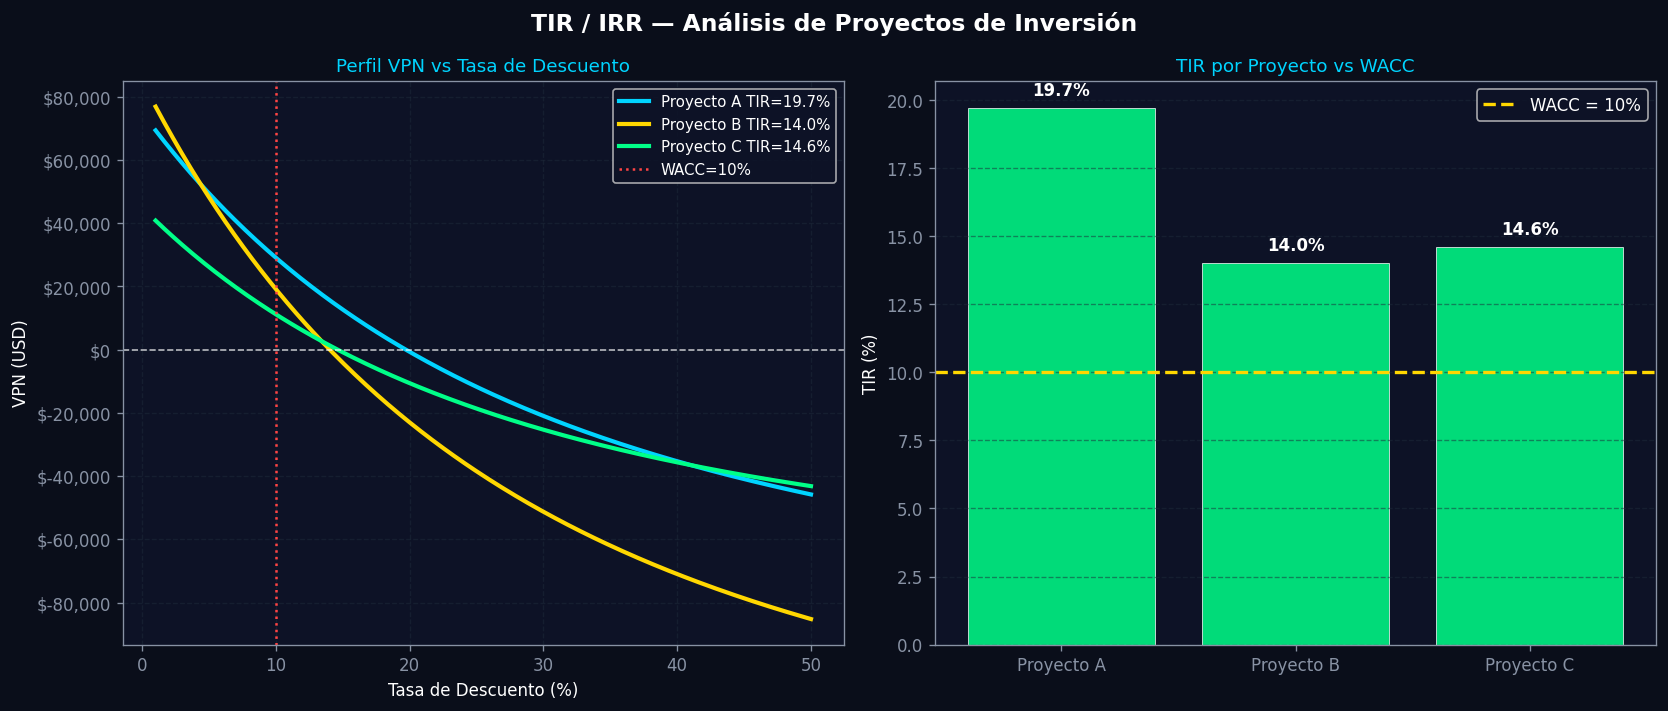

In [8]:
# === TIR / IRR — Cálculo y Análisis ===

def irr(cash_flows):
    """Calcula la TIR usando el método de Brent."""
    try:
        return brentq(lambda r: npv(r, cash_flows), 0.0001, 10.0)
    except ValueError:
        return None

# Proyectos con distintos perfiles de riesgo
proyectos = {
    'Proyecto A (Tecnología)':   [-100_000, 25_000, 30_000, 35_000, 40_000, 45_000],
    'Proyecto B (Expansión)':    [-150_000, 20_000, 35_000, 50_000, 60_000, 70_000],
    'Proyecto C (Conservador)':  [-80_000,  15_000, 20_000, 25_000, 30_000, 35_000],
}
wacc_ref = 0.10

print(f"📊 Análisis TIR vs WACC ({wacc_ref*100:.0f}%):")
irr_results = {}
for nombre, cfs in proyectos.items():
    tir = irr(cfs)
    irr_results[nombre] = tir
    decision = '✅ ACEPTAR' if tir and tir > wacc_ref else '❌ RECHAZAR'
    print(f"  {nombre:<35}: TIR = {tir*100:.2f}%  {decision}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('TIR / IRR — Análisis de Proyectos de Inversión', color=WHITE, fontsize=14, fontweight='bold')

# Panel 1: Perfil VPN
rates_r = np.linspace(0.01, 0.50, 300)
colors_p = [CYAN, GOLD, GREEN]
ax1 = axes[0]
for (nombre, cfs), c in zip(proyectos.items(), colors_p):
    npv_profile = [npv(r, cfs) for r in rates_r]
    tir_val = irr_results[nombre]
    short_name = nombre.split('(')[0].strip()
    ax1.plot(rates_r * 100, npv_profile, color=c, linewidth=2.5, label=f'{short_name} TIR={tir_val*100:.1f}%')
ax1.axhline(0, color=WHITE, linestyle='--', linewidth=1, alpha=0.7)
ax1.axvline(wacc_ref * 100, color=RED, linestyle=':', linewidth=1.5, label=f'WACC={wacc_ref*100:.0f}%')
ax1.set_title('Perfil VPN vs Tasa de Descuento', color=CYAN, fontsize=11)
ax1.set_xlabel('Tasa de Descuento (%)')
ax1.set_ylabel('VPN (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=9)
ax1.grid(True)

# Panel 2: Comparación TIR vs WACC
ax2 = axes[1]
nombres_short = [n.split('(')[0].strip() for n in proyectos.keys()]
tir_vals = [irr_results[n] * 100 for n in proyectos.keys()]
bar_c = [GREEN if t > wacc_ref*100 else RED for t in tir_vals]
bars = ax2.bar(nombres_short, tir_vals, color=bar_c, alpha=0.85, edgecolor=WHITE, linewidth=0.5)
ax2.axhline(wacc_ref * 100, color=GOLD, linestyle='--', linewidth=2, label=f'WACC = {wacc_ref*100:.0f}%')
for bar, val in zip(bars, tir_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', color=WHITE, fontsize=10, fontweight='bold')
ax2.set_title('TIR por Proyecto vs WACC', color=CYAN, fontsize=11)
ax2.set_ylabel('TIR (%)')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.show()


---
## 7. WACC — Costo Promedio Ponderado del Capital <a id='wacc'></a>

> *"El WACC es la tasa mínima de retorno que una empresa debe generar sobre sus activos existentes para satisfacer a sus acreedores, propietarios y otros proveedores de capital."*
> — Koller, Goedhart & Wessels, *Valuation* (2020)

### Fórmula

$$WACC = \frac{E}{V} \cdot K_e + \frac{D}{V} \cdot K_d \cdot (1 - T)$$

| Parámetro | Definición |
|---|---|
| $E$ | Valor de mercado del capital propio |
| $D$ | Valor de mercado de la deuda |
| $V$ | $E + D$ (valor total) |
| $K_e$ | Costo del equity (CAPM) |
| $K_d$ | Costo de la deuda antes de impuestos |
| $T$ | Tasa impositiva marginal |

**Nota:** El WACC es la tasa de descuento apropiada para proyectos con el mismo riesgo que la empresa.


📊 Cálculo del WACC:
  Ke (CAPM) = Rf + β·(Rm-Rf) = 4.5% + 1.2·(10.0%-4.5%) = 11.10%
  Kd (after-tax) = 6.0% × (1 - 25%) = 4.50%
  WACC = 60%×11.10% + 40%×4.50% = 8.46%


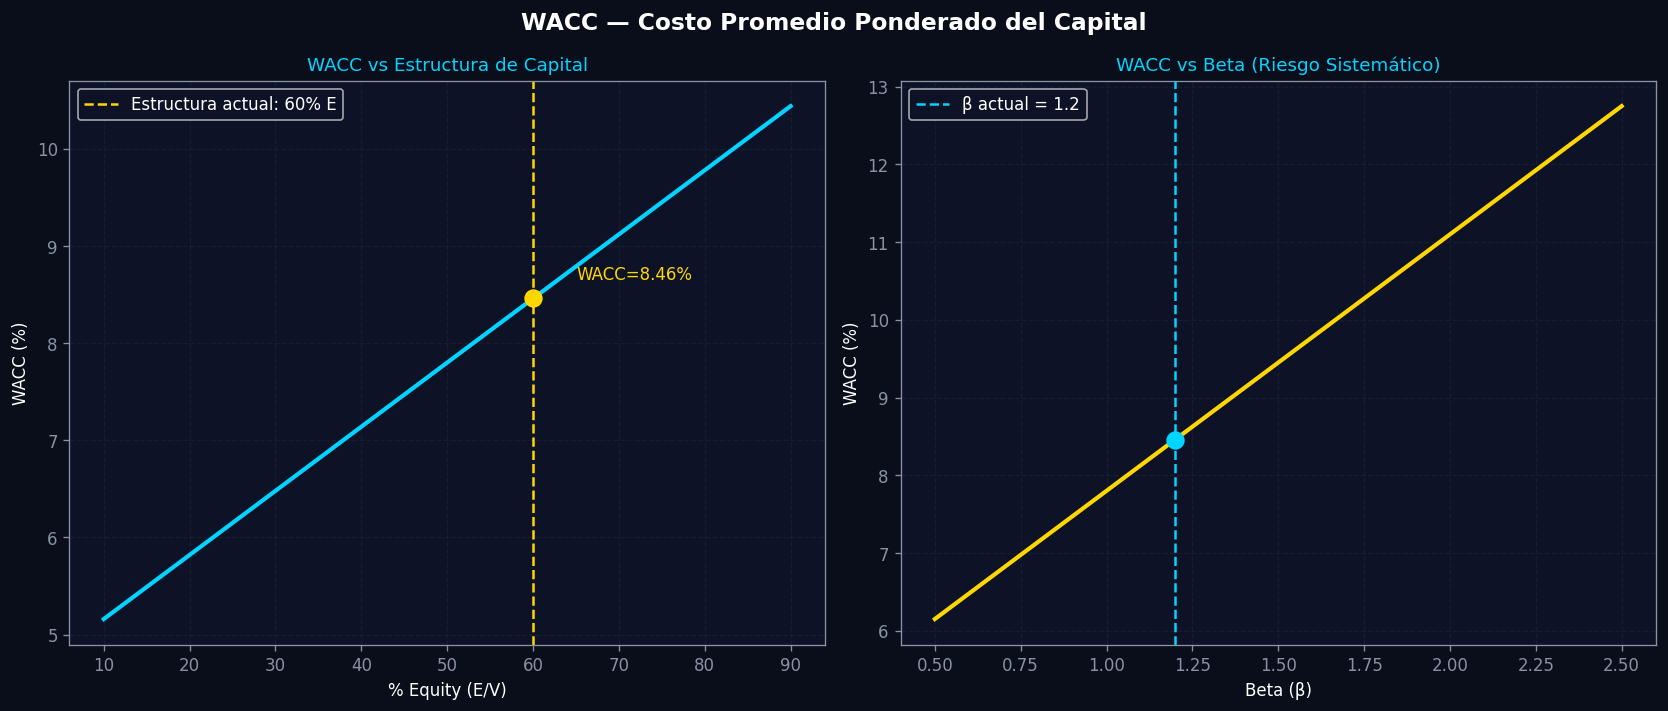

In [9]:
# === WACC — Costo Promedio Ponderado del Capital ===

# Parámetros de ejemplo (empresa tipo S&P 500)
rf = 0.045    # Risk-free rate (T-10 actual)
rm = 0.10     # Retorno esperado del mercado
beta = 1.2    # Beta de la empresa
ke = rf + beta * (rm - rf)  # CAPM

kd = 0.06     # Costo de la deuda
T  = 0.25     # Tasa impositiva

# Estructura de capital
E_pct = 0.60  # 60% equity
D_pct = 0.40  # 40% deuda

wacc_calc = E_pct * ke + D_pct * kd * (1 - T)

print(f"📊 Cálculo del WACC:")
print(f"  Ke (CAPM) = Rf + β·(Rm-Rf) = {rf:.1%} + {beta}·({rm:.1%}-{rf:.1%}) = {ke:.2%}")
print(f"  Kd (after-tax) = {kd:.1%} × (1 - {T:.0%}) = {kd*(1-T):.2%}")
print(f"  WACC = {E_pct:.0%}×{ke:.2%} + {D_pct:.0%}×{kd*(1-T):.2%} = {wacc_calc:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('WACC — Costo Promedio Ponderado del Capital', color=WHITE, fontsize=14, fontweight='bold')

# Panel 1: Sensibilidad WACC a estructura de capital
e_range = np.linspace(0.1, 0.9, 100)
d_range = 1 - e_range
wacc_range = e_range * ke + d_range * kd * (1 - T)

ax1 = axes[0]
ax1.plot(e_range * 100, wacc_range * 100, color=CYAN, linewidth=2.5)
ax1.axvline(E_pct * 100, color=GOLD, linestyle='--', linewidth=1.5, label=f'Estructura actual: {E_pct*100:.0f}% E')
ax1.scatter([E_pct * 100], [wacc_calc * 100], color=GOLD, s=100, zorder=5)
ax1.annotate(f'WACC={wacc_calc:.2%}', xy=(E_pct*100, wacc_calc*100),
             xytext=(E_pct*100+5, wacc_calc*100+0.2), color=GOLD, fontsize=10)
ax1.set_title('WACC vs Estructura de Capital', color=CYAN, fontsize=11)
ax1.set_xlabel('% Equity (E/V)')
ax1.set_ylabel('WACC (%)')
ax1.legend()
ax1.grid(True)

# Panel 2: Sensibilidad WACC a beta
betas = np.linspace(0.5, 2.5, 100)
ke_range = rf + betas * (rm - rf)
wacc_beta = E_pct * ke_range + D_pct * kd * (1 - T)

ax2 = axes[1]
ax2.plot(betas, wacc_beta * 100, color=GOLD, linewidth=2.5)
ax2.axvline(beta, color=CYAN, linestyle='--', linewidth=1.5, label=f'β actual = {beta}')
ax2.scatter([beta], [wacc_calc * 100], color=CYAN, s=100, zorder=5)
ax2.set_title('WACC vs Beta (Riesgo Sistemático)', color=CYAN, fontsize=11)
ax2.set_xlabel('Beta (β)')
ax2.set_ylabel('WACC (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


---
## Resumen: 7 Fórmulas del Valor del Dinero en el Tiempo

| # | Fórmula | Aplicación Principal |
|---|---|---|
| 1 | $$FV = PV \times (1+r)^n$$ | Capitalización de inversiones |
| 2 | $$PV = FV / (1+r)^n$$ | Descuento de flujos futuros |
| 3 | $$A = P \cdot e^{rt}$$ | Derivados financieros, bonos |
| 4 | $$VPN = \sum CF_t/(1+r)^t - I_0$$ | Evaluación de proyectos |
| 5 | $$CAGR = (VF/VI)^{1/n} - 1$$ | Comparación de rendimientos |
| 6 | $$0 = \sum CF_t/(1+TIR)^t$$ | Decisión de inversión |
| 7 | $$WACC = (E/V)K_e + (D/V)K_d(1-T)$$ | Tasa de descuento corporativa |

---

### Próximos Pasos
- 📘 **eBook Finanzas 5.0:** Profundiza en cada fórmula con casos reales
- 🎓 **Curso Python para Finanzas 5.0:** Implementa modelos completos de valoración DCF
- 💬 **Comenta TIEMPO** en Instagram para recibir este notebook

*WP Wellness Academy · Curso Python para Finanzas 5.0*
